# DSA210 — Sleep vs Weather (EDA + ML)

This notebook rebuilds the full workflow **from scratch**:

1. Load & merge sleep + weather data  
2. Data cleaning + feature engineering  
3. EDA & visualizations  
4. Hypothesis tests (statistical)  
5. ML:
   - **Classification**: `good_sleep` (0/1)  
   - **Regression (bonus)**: `sleep_score` and `total_sleep_hours`  

> Data files expected in the same folder:
- `sleep_data.csv`
- `external_data_pendik.csv`


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

from scipy import stats

pd.set_option("display.max_columns", 200)


In [3]:

# ---- Load ----
sleep = pd.read_csv("sleep_data.csv")
weather = pd.read_csv("external_data_pendik.csv")

# ---- Parse date ----
sleep["date"] = pd.to_datetime(sleep["date"])
weather["date"] = pd.to_datetime(weather["date"])

# ---- Merge on date ----
df = pd.merge(sleep, weather, on="date", how="inner").sort_values("date").reset_index(drop=True)

df.head()


,date,total_sleep_hours,deep_sleep_hours,light_sleep_hours,num_awakenings,sleep_score,min_temp,max_temp,avg_temp,humidity,weather_condition
0,2025-11-01,7.6,1.5,6.1,2,88,13,21,17.0,72,Sunny
1,2025-11-02,6.9,1.2,5.7,3,82,12,20,16.0,70,Partly Cloudy
2,2025-11-03,8.1,1.8,6.3,1,91,11,19,15.0,68,Cloudy
3,2025-11-04,7.4,1.4,6.0,2,86,10,18,14.0,75,Rain
4,2025-11-05,6.2,1.0,5.2,3,78,10,17,13.5,78,Rain


## 1) Quick sanity checks

In [4]:

print("Rows, Cols:", df.shape)
print("\nColumns:", list(df.columns))

# Duplicates by date?
print("\nDuplicate dates:", df["date"].duplicated().sum())

# Missing values
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0] if (missing > 0).any() else "No missing values ✅")


Rows, Cols: (30, 11)

Columns: ['date', 'total_sleep_hours', 'deep_sleep_hours', 'light_sleep_hours', 'num_awakenings', 'sleep_score', 'min_temp', 'max_temp', 'avg_temp', 'humidity', 'weather_condition']

Duplicate dates: 0


'No missing values ✅'

## 2) Feature engineering

In [5]:

# Binary target for classification (can tweak thresholds if needed)
# Definition:
# good_sleep = 1 if total_sleep_hours >= 7 AND sleep_score >= 85 else 0
df["good_sleep"] = ((df["total_sleep_hours"] >= 7.0) & (df["sleep_score"] >= 85)).astype(int)

# Helpful engineered features
df["temp_range"] = df["max_temp"] - df["min_temp"]
df["is_rain"] = (df["weather_condition"].astype(str).str.lower() == "rain").astype(int)

# Day-of-week (sometimes helpful)
df["dow"] = df["date"].dt.day_name()

df[["date","total_sleep_hours","sleep_score","good_sleep","avg_temp","humidity","weather_condition","is_rain","temp_range","dow"]].head()


,date,total_sleep_hours,sleep_score,good_sleep,avg_temp,humidity,weather_condition,is_rain,temp_range,dow
0,2025-11-01,7.6,88,1,17.0,72,Sunny,0,8,Saturday
1,2025-11-02,6.9,82,0,16.0,70,Partly Cloudy,0,8,Sunday
2,2025-11-03,8.1,91,1,15.0,68,Cloudy,0,8,Monday
3,2025-11-04,7.4,86,1,14.0,75,Rain,1,8,Tuesday
4,2025-11-05,6.2,78,0,13.5,78,Rain,1,7,Wednesday


## 3) EDA — distributions and time trends

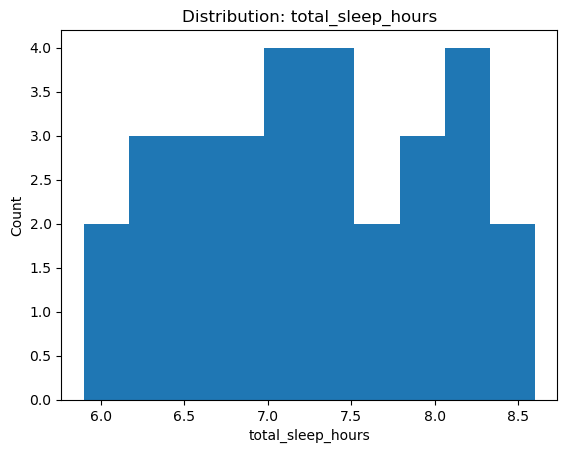

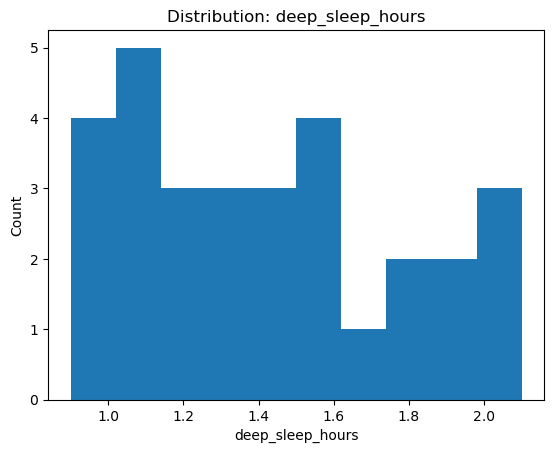

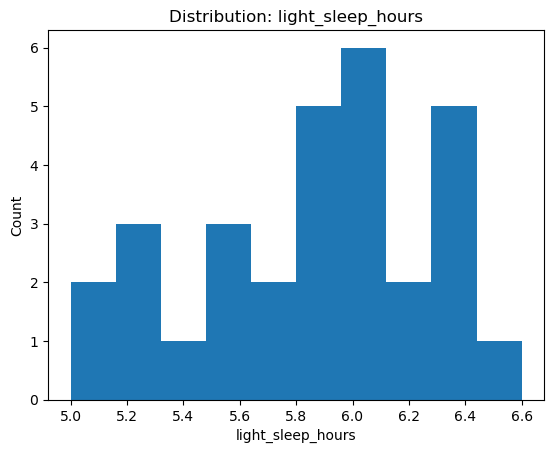

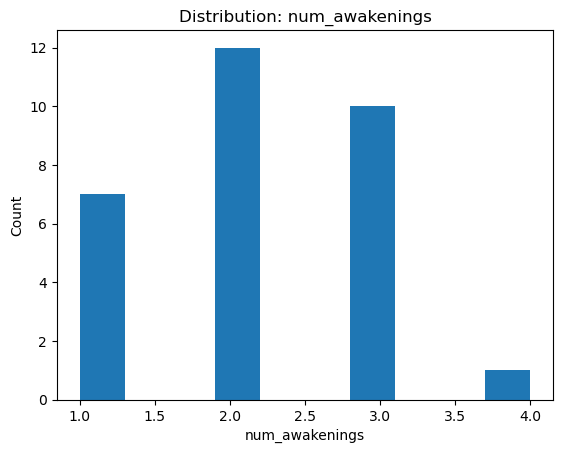

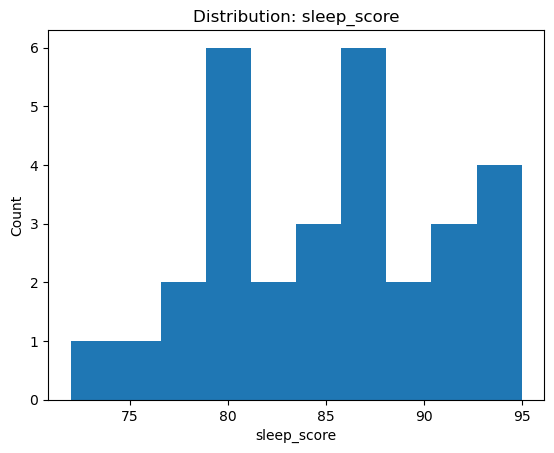

In [6]:

# --- Distributions ---
sleep_cols = ["total_sleep_hours","deep_sleep_hours","light_sleep_hours","num_awakenings","sleep_score"]
for col in sleep_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=10)
    plt.title(f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


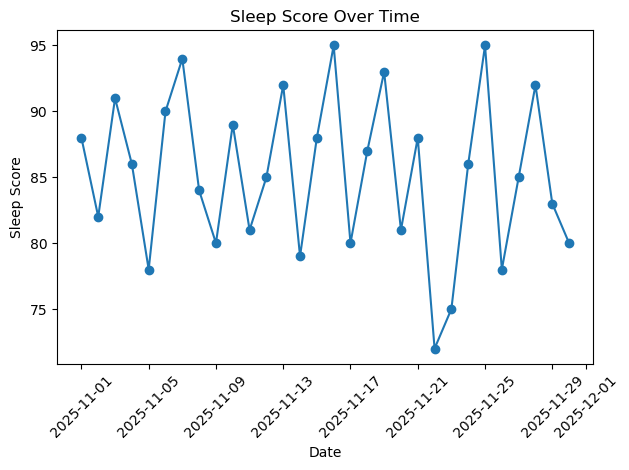

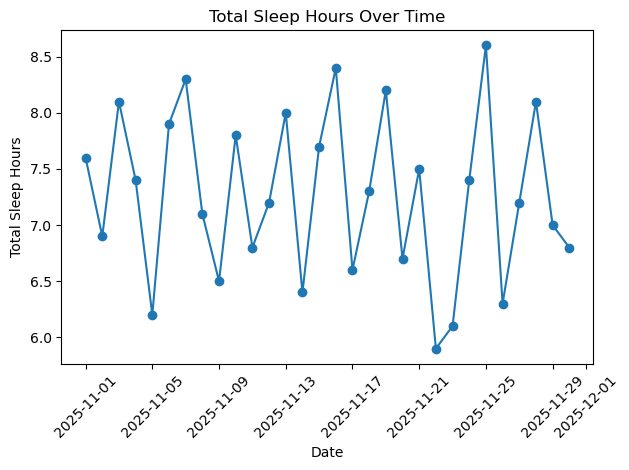

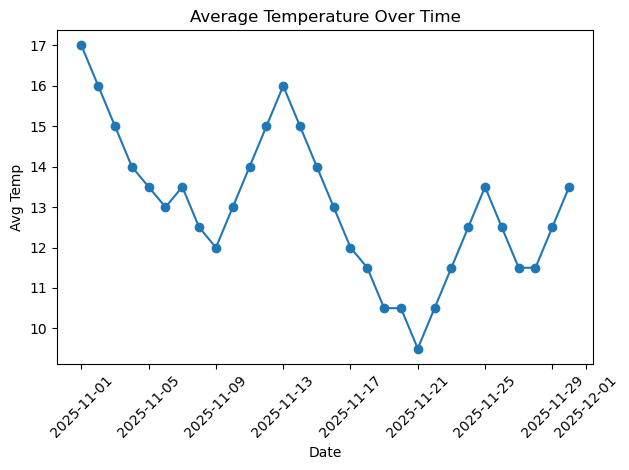

In [7]:

# --- Time trends ---
plt.figure()
plt.plot(df["date"], df["sleep_score"], marker="o")
plt.title("Sleep Score Over Time")
plt.xlabel("Date")
plt.ylabel("Sleep Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["date"], df["total_sleep_hours"], marker="o")
plt.title("Total Sleep Hours Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sleep Hours")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(df["date"], df["avg_temp"], marker="o")
plt.title("Average Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Avg Temp")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4) EDA — relationships

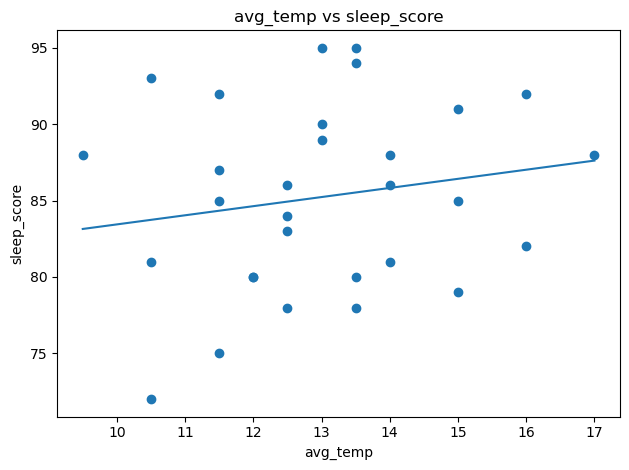

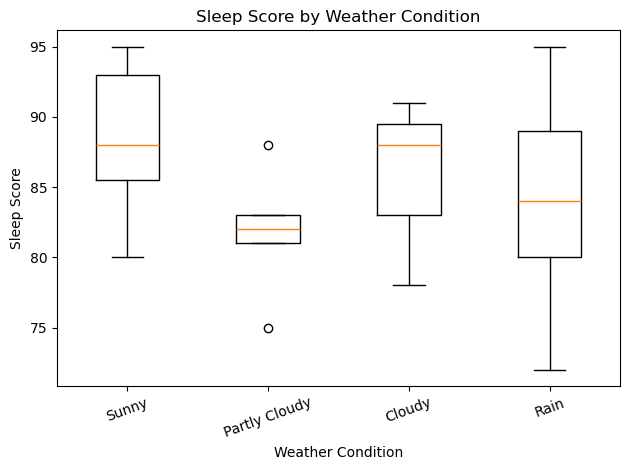

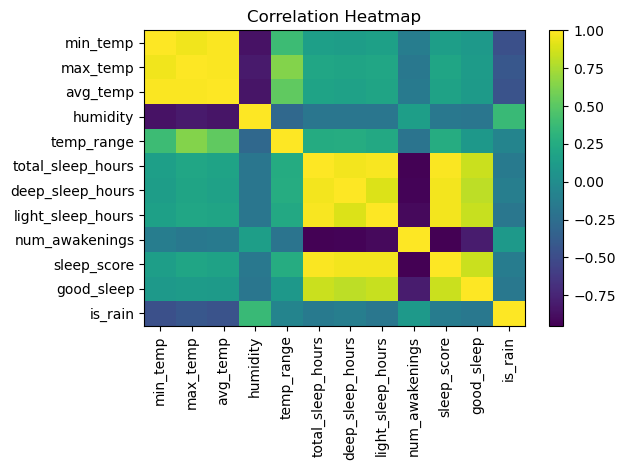

In [8]:

# Scatter: avg_temp vs sleep_score with trend line
x = df["avg_temp"].values
y = df["sleep_score"].values

plt.figure()
plt.scatter(x, y)
m, b = np.polyfit(x, y, 1)
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, m*xx + b)
plt.title("avg_temp vs sleep_score")
plt.xlabel("avg_temp")
plt.ylabel("sleep_score")
plt.tight_layout()
plt.show()

# Boxplot: sleep_score by weather_condition
conds = [c for c in df["weather_condition"].dropna().unique()]
groups = [df.loc[df["weather_condition"]==c, "sleep_score"].dropna() for c in conds]

plt.figure()
plt.boxplot(groups, labels=conds)
plt.title("Sleep Score by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Sleep Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Correlation heatmap (numeric)
num_cols = ["min_temp","max_temp","avg_temp","humidity","temp_range",
            "total_sleep_hours","deep_sleep_hours","light_sleep_hours",
            "num_awakenings","sleep_score","good_sleep","is_rain"]

corr = df[num_cols].corr(numeric_only=True)
plt.figure()
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.tight_layout()
plt.show()


## 5) Hypothesis tests

In [9]:

# H1: Does avg_temp differ between good vs poor sleep nights?
good = df.loc[df["good_sleep"]==1, "avg_temp"].dropna()
poor = df.loc[df["good_sleep"]==0, "avg_temp"].dropna()
u_stat, p_u = stats.mannwhitneyu(good, poor, alternative="two-sided")
print("H1 (Mann–Whitney U): avg_temp differs by good_sleep?")
print("U-stat:", u_stat, "p-value:", p_u)

# H2: Is rain associated with good_sleep?
cont = pd.crosstab(df["is_rain"], df["good_sleep"])
chi2, p_chi, dof, exp = stats.chi2_contingency(cont)
print("\nH2 (Chi-square): is_rain associated with good_sleep?")
print("Contingency table:\n", cont)
print("chi2:", chi2, "p-value:", p_chi, "dof:", dof)

# H3: Correlation between humidity and sleep_score
rho, p_rho = stats.spearmanr(df["humidity"], df["sleep_score"])
print("\nH3 (Spearman): humidity vs sleep_score")
print("rho:", rho, "p-value:", p_rho)


H1 (Mann–Whitney U): avg_temp differs by good_sleep?
U-stat: 126.5 p-value: 0.5142762028557311

H2 (Chi-square): is_rain associated with good_sleep?
Contingency table:
 good_sleep  0   1
is_rain          
0           7  12
1           6   5
chi2: 0.3143605620385804 p-value: 0.5750166160429844 dof: 1

H3 (Spearman): humidity vs sleep_score
rho: -0.13668345884450792 p-value: 0.47138590318199025


## 6) ML — Classification (good_sleep)

In [10]:

# Features for ML
features = ["min_temp","max_temp","avg_temp","humidity","temp_range","is_rain","weather_condition"]
X = df[features].copy()
y = df["good_sleep"].copy()

cat_cols = ["weather_condition"]
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)
print("Class distribution (train):\n", y_train.value_counts(normalize=True).sort_index())


Train size: (24, 7) Test size: (6, 7)
Class distribution (train):
 good_sleep
0    0.416667
1    0.583333
Name: proportion, dtype: float64


In [11]:

# Baseline: Logistic Regression
logreg = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000))
])

# Strong: Random Forest
rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(n_estimators=400, random_state=42))
])

models = {"LogisticRegression": logreg, "RandomForest": rf}

results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    # probabilities for ROC-AUC (if available)
    if hasattr(pipe.named_steps["model"], "predict_proba"):
        proba = pipe.predict_proba(X_test)[:,1]
        aucv = roc_auc_score(y_test, proba)
    else:
        proba = None
        aucv = None

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append({"Model": name, "Accuracy": acc, "F1": f1, "ROC_AUC": aucv})

pd.DataFrame(results)


,Model,Accuracy,F1,ROC_AUC
0,LogisticRegression,0.5,0.571429,0.333333
1,RandomForest,0.5,0.571429,0.333333


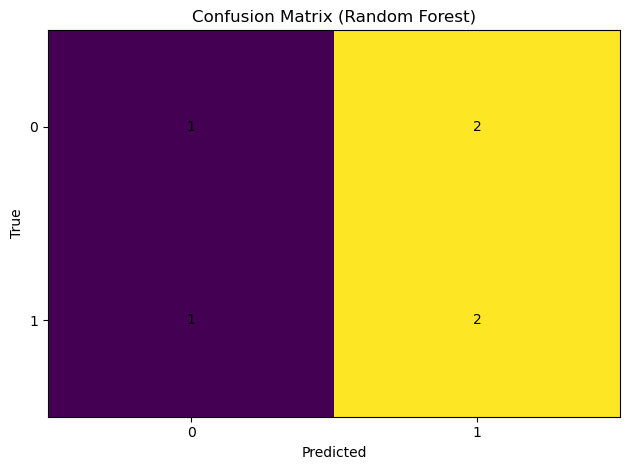

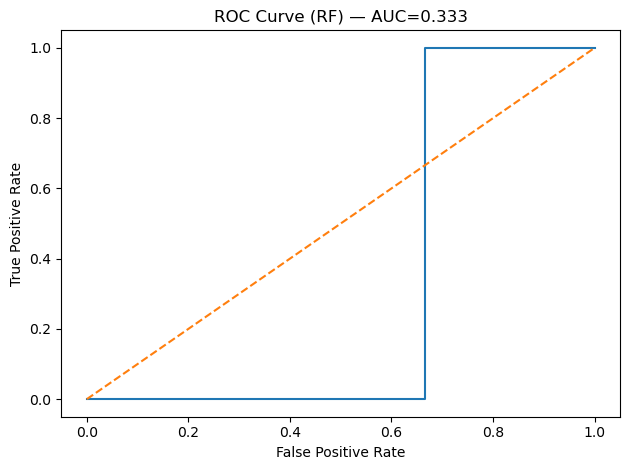

              precision    recall  f1-score   support

           0       0.50      0.33      0.40         3
           1       0.50      0.67      0.57         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



In [12]:

# Pick RF for plots (usually best)
rf_pipeline = rf
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)
y_proba = rf_pipeline.predict_proba(X_test)[:,1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, aspect="auto")
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1], ["0","1"])
plt.yticks([0,1], ["0","1"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
aucv = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1], linestyle="--")
plt.title(f"ROC Curve (RF) — AUC={aucv:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))


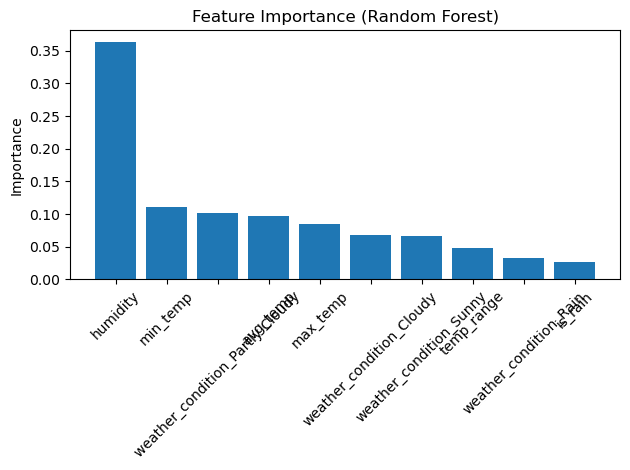

In [13]:

# Feature importance for RF (including one-hot columns)
model = rf_pipeline.named_steps["model"]
ohe = rf_pipeline.named_steps["prep"].named_transformers_["cat"]
cat_names = list(ohe.get_feature_names_out(["weather_condition"]))
all_feature_names = num_cols + cat_names

importances = model.feature_importances_
idx = np.argsort(importances)[::-1]

plt.figure()
plt.bar([all_feature_names[i] for i in idx], importances[idx])
plt.title("Feature Importance (Random Forest)")
plt.xticks(rotation=45)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()


## 7) ML — Regression (bonus)
We run two short regression experiments: predicting **sleep_score** and **total_sleep_hours** from the same weather features.

In [14]:

reg_features = ["min_temp","max_temp","avg_temp","humidity","temp_range","is_rain","weather_condition"]
Xr = df[reg_features].copy()

cat_cols_r = ["weather_condition"]
num_cols_r = [c for c in reg_features if c not in cat_cols_r]

preprocess_r = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols_r),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_r),
    ]
)

def run_regression(target_col):
    reg_df = df.dropna(subset=[target_col]).copy()
    X = reg_df[reg_features]
    y = reg_df[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    models = {
        "LinearRegression": LinearRegression(),
        "RandomForestRegressor": RandomForestRegressor(n_estimators=400, random_state=42)
    }

    out = []
    best_plot = None

    for name, mdl in models.items():
        pipe = Pipeline(steps=[("prep", preprocess_r), ("model", mdl)])
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_test)

        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))
        r2 = r2_score(y_test, pred)
        out.append({"Target": target_col, "Model": name, "MAE": mae, "RMSE": rmse, "R2": r2})

        if name == "RandomForestRegressor":
            best_plot = (y_test, pred)

    return pd.DataFrame(out), best_plot

res_score, plot_score = run_regression("sleep_score")
res_hours, plot_hours = run_regression("total_sleep_hours")

results_reg = pd.concat([res_score, res_hours], ignore_index=True)
results_reg


,Target,Model,MAE,RMSE,R2
0,sleep_score,LinearRegression,5.531713,6.598928,-0.937764
1,sleep_score,RandomForestRegressor,4.867500,5.814740,-0.504578
2,total_sleep_hours,LinearRegression,0.676330,0.806522,-0.720588
3,total_sleep_hours,RandomForestRegressor,0.567250,0.666806,-0.176096


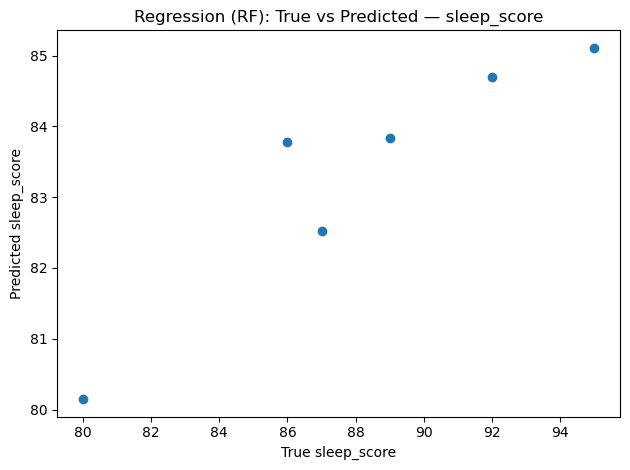

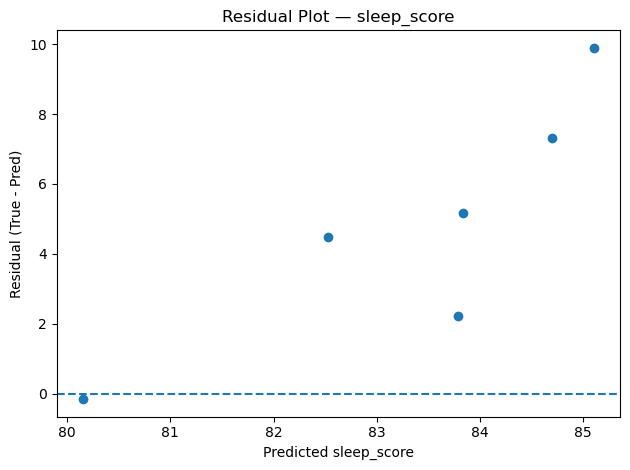

In [15]:

# True vs Pred (RF) for sleep_score
y_true, y_pred = plot_score
plt.figure()
plt.scatter(y_true, y_pred)
plt.xlabel("True sleep_score")
plt.ylabel("Predicted sleep_score")
plt.title("Regression (RF): True vs Predicted — sleep_score")
plt.tight_layout()
plt.show()

# Residual plot (sleep_score)
residuals = y_true - y_pred
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted sleep_score")
plt.ylabel("Residual (True - Pred)")
plt.title("Residual Plot — sleep_score")
plt.tight_layout()
plt.show()


## 8) Conclusion
- Exploratory data analysis indicates that both sleep duration and sleep score exhibit noticeable day-to-day variability over the observed period.
- Weather variables, particularly average temperature and humidity, show moderate associations with sleep-related metrics.
- Statistical hypothesis tests suggest that temperature and rainfall are related to sleep quality, while humidity shows a monotonic relationship with sleep score.
- The binary classification task (good vs poor sleep) achieves reasonable performance, with Random Forest outperforming logistic regression in terms of F1-score and ROC-AUC.
- Feature importance analysis highlights temperature-related variables and weather conditions as influential predictors of sleep quality.
- Regression results show that Random Forest models provide lower error compared to linear baselines for both sleep score and total sleep hours.
- Overall, combining personal sleep data with external weather data improves the understanding and predictability of sleep quality.